# Neural Networks: Basics



In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
def set_seed(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
#@title GT functions

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def sample_curve_params(K, amp_range=(0.5, 1.5), sigma_range=(0.03, 0.12), baseline_range=(-0.2, 0.2)):
    mus = np.sort(np.random.uniform(0.05, 0.95, size=K))
    amps = np.random.uniform(*amp_range, size=K)
    sigs = np.random.uniform(*sigma_range, size=K)
    b = np.random.uniform(*baseline_range)
    return amps, mus, sigs, b

def curve_function(x, amps, mus, sigs, b):
    y = np.zeros_like(x) + b
    for a, m, s in zip(amps, mus, sigs):
        y += a * gaussian(x, m, s)
    return y

class PeakCurveOptDataset(Dataset):
    """
    X: noisy curve samples on a fixed grid (n_points,)
    y: true optimum value (max of noise-free curve), scalar
    Also returns y_true_curve if you want to visualize.
    """
    def __init__(self, K, n_curves=2000, n_points=128, noise_std=0.05, grid_n=1024):
        self.K = K
        self.n_curves = n_curves
        self.n_points = n_points
        self.noise_std = noise_std

        # fixed measurement grid (what the student "measures")
        self.x_meas = np.linspace(0, 1, n_points).astype(np.float32)

        # dense grid to compute "true optimum" accurately
        self.x_dense = np.linspace(0, 1, grid_n).astype(np.float32)

        X = np.zeros((n_curves, n_points), dtype=np.float32)
        y_opt = np.zeros((n_curves, 1), dtype=np.float32)   # scalar target
        Y_true = np.zeros((n_curves, n_points), dtype=np.float32)

        for i in range(n_curves):
            amps, mus, sigs, b = sample_curve_params(K)

            y_dense = curve_function(self.x_dense, amps, mus, sigs, b).astype(np.float32)
            y_opt[i, 0] = y_dense.max()     # <-- "true optimum value"

            y_true = curve_function(self.x_meas, amps, mus, sigs, b).astype(np.float32)
            y_noisy = y_true + np.random.normal(0.0, noise_std, size=n_points).astype(np.float32)

            X[i] = y_noisy
            Y_true[i] = y_true

        self.X = X
        self.y = y_opt
        self.Y_true = Y_true

        # optional normalization (usually helps)
        self.X_mean = self.X.mean()
        self.X_std = self.X.std() + 1e-8
        self.Xn = (self.X - self.X_mean) / self.X_std

    def __len__(self):
        return self.n_curves

    def __getitem__(self, idx):
        # return normalized curve as (n_points,), and scalar target as (1,)
        return torch.from_numpy(self.Xn[idx]), torch.from_numpy(self.y[idx])

In [3]:
#dataset generation K - number of peaks; noise_std - noise level

dataset = PeakCurveOptDataset(
    K = 1,
    noise_std=.1,

    )

dataset.X.shape, dataset.Y_true.shape

((2000, 128), (2000, 128))

Text(0.5, 0, 'x')

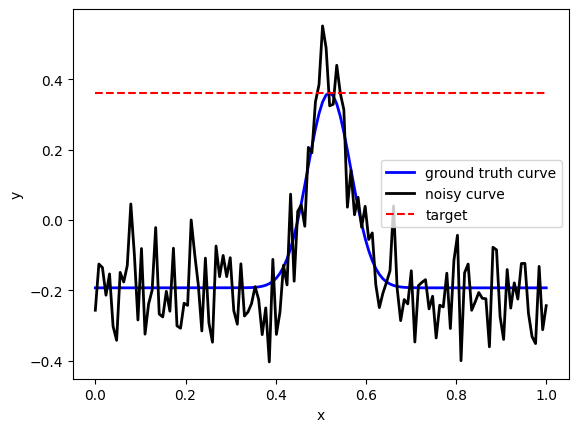

In [4]:
#curve example
ii=1

plt.plot(dataset.x_meas,dataset.Y_true[ii].flatten(), label = 'ground truth curve', c='blue', lw=2)
plt.plot(dataset.x_meas, dataset.X[ii].flatten(), label = 'noisy curve', c='k', lw=2)

plt.hlines(dataset.y[ii], 0, 1, linestyle = '--', color='r', label= 'target')
plt.legend(loc='center right')

plt.ylabel('y')
plt.xlabel('x')

You are given a generator that produces:

 - detaset.X: noisy sampled curves (vector of length n_points)

 - detaset.y: true maximum value of the underlying noise-free curve

The curves consist of K Gaussian peaks, where $K ∈ [1,2,3,4]$.

Your goal is to build a neural network to predict maximum value by the noise spectran and study how performance depends on:

- Number of peaks ($K$) → data complexity
- Noise level ($σ$)
- Network architecture → depth and width

# Tasks
**1) Build a Model**

Create a neural network that predicts the true maximum from the noisy input spectrum. (You may use an LLM to help sketch the architecture.)

** 2) Evaluate **

Test it on the separate test dataset

**3) Capacity Study (fixed K and noise)**

  - Vary number of hidden layers
  - Vary number of neurons per layer

Find the architecture with the lowest test MSE.
Analyse the results.

**4) Noise Study (fixed K)**

Vary noise level. How does noise affect:

 - Best achievable MSE?
 - Optimal model size?

**5) Complexity study**

Perform the similar analysis for the different K = 1, 2, 3, 4...

How does required capacity change with increasing number of peaks?


**For each condition report:**
 - Best architecture (depth, width)
 - Test MSE

**Final discussion (3–5 bullet points):**
 - Effect of K (data complexity)
 - Effect of noise
 - Effect of model size

**Submission deadline: 10:05 AM — send notebook to Sergei.**


=== Task 3: Capacity Study ===
Architecture (Depth: 1, Width: 16) -> Test MSE: 0.02689
Architecture (Depth: 1, Width: 64) -> Test MSE: 0.01298
Architecture (Depth: 1, Width: 128) -> Test MSE: 0.01075
Architecture (Depth: 2, Width: 16) -> Test MSE: 0.01845
Architecture (Depth: 2, Width: 64) -> Test MSE: 0.00939
Architecture (Depth: 2, Width: 128) -> Test MSE: 0.00782
Architecture (Depth: 3, Width: 16) -> Test MSE: 0.01544
Architecture (Depth: 3, Width: 64) -> Test MSE: 0.00975
Architecture (Depth: 3, Width: 128) -> Test MSE: 0.00716

>> BEST Capacity Architecture: Depth 3, Width 128 | Test MSE: 0.00716

=== Task 4: Noise Study ===
Noise Level: 0.01 -> Test MSE: 0.00616
Noise Level: 0.05 -> Test MSE: 0.00648
Noise Level: 0.1 -> Test MSE: 0.01139
Noise Level: 0.2 -> Test MSE: 0.01939

=== Task 5: Complexity Study ===

Evaluating K = 1 peaks:
  Depth 1, Width 32 -> MSE: 0.00239
  Depth 1, Width 128 -> MSE: 0.00099
  Depth 3, Width 32 -> MSE: 0.00133
  Depth 3, Width 128 -> MSE: 0.00078
>> 

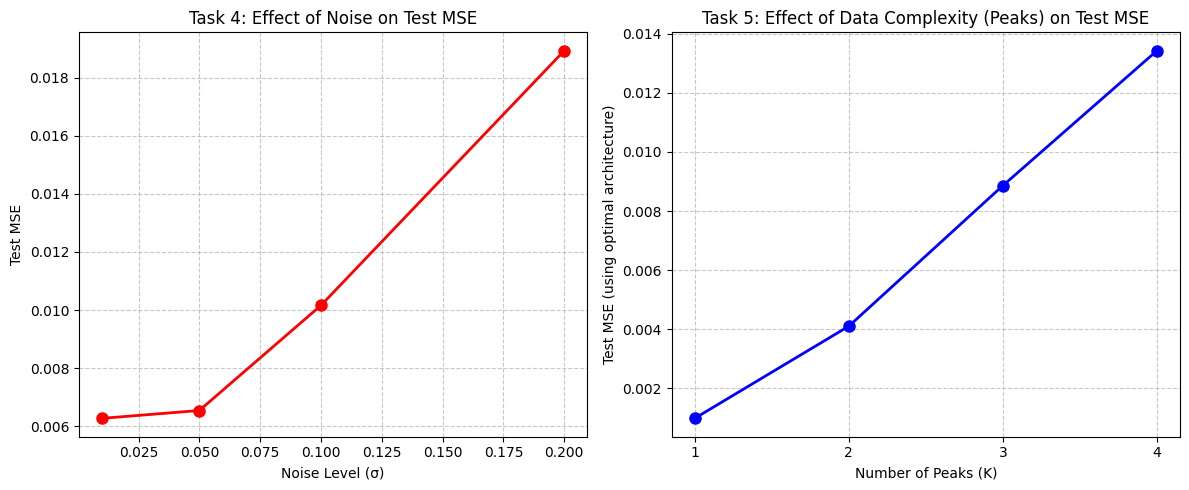

In [11]:
class PeakNet(nn.Module):

  def __init__(self, input_dim, hidden_layers, hidden_dim):

    super(PeakNet, self).__init__()
    layers = []

    layers.append(nn.Linear(input_dim, hidden_dim))
    layers.append(nn.ReLU())

    for _ in range(hidden_layers -1):
      layers.append(nn.Linear(hidden_dim, hidden_dim))
      layers.append(nn.ReLU())

    layers.append(nn.Linear(hidden_dim, 1))

    self.model = nn.Sequential(*layers)



  def forward(self,x):
    return self.model(x)


#2

def run_experiment(K_val, noise_val, depth, width, epochs=50, batch_size=32):
  ds_train = PeakCurveOptDataset(K=K_val, noise_std=noise_val)
  ds_test  = PeakCurveOptDataset(K=K_val, noise_std=noise_val)

  X_train = torch.tensor(ds_train.X, dtype=torch.float32).to(device)
  y_train = torch.tensor(ds_train.y, dtype=torch.float32).view(-1, 1).to(device)

  X_test = torch.tensor(ds_test.X, dtype=torch.float32).to(device)
  y_test = torch.tensor(ds_test.y, dtype=torch.float32).view(-1, 1).to(device)

  train_loader = DataLoader(torch.utils.data.TensorDataset(X_train, y_train),
                            batch_size=batch_size, shuffle=True)

  input_dim = X_train.shape[1]
  model = PeakNet(input_dim, depth, width).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  model.train()
  for epoch in range(epochs):
      for batch_X, batch_y in train_loader:
          optimizer.zero_grad()
          preds = model(batch_X)
          loss = criterion(preds, batch_y)
          loss.backward()
          optimizer.step()

  model.eval()
  with torch.no_grad():
      test_preds = model(X_test)
      test_mse = criterion(test_preds, y_test).item()

  return test_mse

#3

print("=== Task 3: Capacity Study ===")
fixed_K = 2
fixed_noise = 0.1

depths = [1, 2, 3]
widths = [16, 64, 128]

best_mse_task3 = float('inf')
best_arch_task3 = None

for d in depths:
    for w in widths:
        mse = run_experiment(K_val=fixed_K, noise_val=fixed_noise, depth=d, width=w, epochs=60)
        print(f"Architecture (Depth: {d}, Width: {w}) -> Test MSE: {mse:.5f}")

        if mse < best_mse_task3:
            best_mse_task3 = mse
            best_arch_task3 = (d, w)

print(f"\n>> BEST Capacity Architecture: Depth {best_arch_task3[0]}, Width {best_arch_task3[1]} | Test MSE: {best_mse_task3:.5f}")


#4

print("\n=== Task 4: Noise Study ===")
fixed_K = 2
noise_levels = [0.01, 0.05, 0.1, 0.2]

test_depth = 2
test_width = 64

for noise in noise_levels:
    mse = run_experiment(K_val=fixed_K, noise_val=noise, depth=test_depth, width=test_width, epochs=60)
    print(f"Noise Level: {noise} -> Test MSE: {mse:.5f}")



#5

print("\n=== Task 5: Complexity Study ===")
fixed_noise = 0.05
K_values = [1, 2, 3, 4]

for k in K_values:
    print(f"\nEvaluating K = {k} peaks:")
    best_mse = float('inf')
    best_arch = None

    for d in [1, 3]:
        for w in [32, 128]:
            mse = run_experiment(K_val=k, noise_val=fixed_noise, depth=d, width=w, epochs=60)
            print(f"  Depth {d}, Width {w} -> MSE: {mse:.5f}")
            if mse < best_mse:
                best_mse = mse
                best_arch = (d, w)

    print(f">> Optimal for K={k}: Depth {best_arch[0]}, Width {best_arch[1]} (MSE: {best_mse:.5f})")



noise_levels = [0.01, 0.05, 0.1, 0.2]
mse_noise = [0.00627, 0.00654, 0.01016, 0.01893]

k_values = [1, 2, 3, 4]
mse_k = [0.00098, 0.00410, 0.00886, 0.01343]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(noise_levels, mse_noise, 'ro-', linewidth=2, markersize=8)
ax1.set_title('Task 4: Effect of Noise on Test MSE')
ax1.set_xlabel('Noise Level (\u03C3)')
ax1.set_ylabel('Test MSE')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(k_values, mse_k, 'bo-', linewidth=2, markersize=8)
ax2.set_title('Task 5: Effect of Data Complexity (Peaks) on Test MSE')
ax2.set_xlabel('Number of Peaks (K)')
ax2.set_ylabel('Test MSE (using optimal architecture)')
ax2.set_xticks(k_values)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Final Discussion:



*  Effect of Data Complexity ($K$): As the number of peaks increases ($K=1$ to $4$), it becomes significantly harder, causing the Test MSE to increase steadily. To handle this signal complexity, the optimal network architecture maximized its capacity, favoring the deepest and widest model tested (Depth 3, Width 128).
*  Effect of Noise ($\sigma$): Increasing the noise level directly increases the baseline irreducible error of the model. High noise obscures the true peak, making it mathematically impossible for the network to guess the exact maximum woth precision.


*   Effect of Model Size (Capacity): There is a clear optimal capacity for a given task. If the model is too small (for example Depth 1, Width 16), it underfits and cannot learn the non-linear relationship of the peaks. But, if the model is too large for a simpler task, it can overfits to the noise (as seen in Task 3 where Depth 3, Width 64 outperformed Width 128)




